## Composite 

### Import package

In [1]:
import os
import sys

import numpy as np
import netCDF4 as nc

from pathlib import Path
from datetime import datetime
from scipy.ndimage import convolve1d, minimum_filter
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import spectrum #type: ignore

### Helper Functions

In [2]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a netCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    dates_array = np.asarray(dates).ravel()
    return np.asarray(
        [date.strftime("%Y-%m-%d") for date in dates_array],
        dtype=str,
    )

def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a netCDF array to float and replace masked values by NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float32)
    return np.asarray(masked_values.filled(np.nan))

### Identifying the KW

#### Load OLR

In [3]:
START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

with nc.Dataset("/work/DATA/Satellite/OLR/olr_anomaly.nc", "r") as olr_ds:
    all_olr_dates: np.ndarray = convert_time(olr_ds.variables["time"])
    olr_lat  : np.ndarray = as_float_array(olr_ds.variables["lat"][...])
    olr_lon  : np.ndarray = as_float_array(olr_ds.variables["lon"][...])

    time_mask = (all_olr_dates >= START_DATE) & (all_olr_dates < END_DATE)
    lat_mask  = (olr_lat >= LATITUDE_BOUNDS[0]) & (olr_lat <= LATITUDE_BOUNDS[1])

    olr      : np.ndarray = as_float_array(
        olr_ds.variables["olr"][
            time_mask, lat_mask, :
        ]
    )
    olr_dates: np.ndarray = all_olr_dates[time_mask]

olr_nt, olr_ny, olr_nx = olr.shape

#### Preprocessing

In [4]:
# remove time and zonal mean
olr_anom: np.ndarray = olr - np.nanmean(olr, axis=(0, -1), keepdims=True)

# symmetrizing data
olr_symm: np.ndarray = spectrum.symm_asym(olr_anom, lat_axis=1)[0].mean(axis=1)

#### Transform

In [5]:
# set wavenumber and frequency
wnum: np.ndarray = np.fft.fftfreq(olr_nx, d=1/olr_nx)
freq: np.ndarray = np.fft.fftfreq(olr_nt, d=1)

wnums, freqs = np.meshgrid(wnum, freq)

# FFT transform
olr_fft: np.ndarray = np.fft.fft(np.fft.ifft(olr_symm, axis=0), axis=1)

# apply masking
def kelvin_disprel(
        edep: float,
        wnum: np.ndarray
) -> np.ndarray:

    return np.sqrt(9.81 * edep) * 86400.0 / (2*np.pi*6.371e6) * wnum

wnum_lim = ((wnums >= 3) & (wnums <= 8)) | ((wnums <= -3) & (wnums >= -8))
freq_lim = ((freqs >= 1/20) & (freqs <= 1/2.5)) | ((freqs <= -1/20) & (freqs >= -1/2.5))
edep_lim = (freqs >= kelvin_disprel(8, wnums)) & (freqs <= kelvin_disprel(90, wnums)) | \
    (freqs <= kelvin_disprel(8, wnums)) & (freqs >= kelvin_disprel(90, wnums))

mask = wnum_lim & freq_lim & edep_lim

olr_mask = np.where(mask, olr_fft, 0.0)

# IFFT transform
Kelvin_recon: np.ndarray = np.fft.ifft(np.fft.fft(olr_mask, axis=0), axis=1).real


#### Select significant events

In [6]:
# Calculate statistics
mean: float = Kelvin_recon.flatten().mean()
std : float = Kelvin_recon.flatten().std()

threshold: float = mean - 2.96 * std

# Periodic neighborhood in longitude; adjust zonal size as appropriate
local_minimum = (
    Kelvin_recon
    == minimum_filter(
        Kelvin_recon,
        size=(1, 81),       # 81 longitude grid points, represents 50 degree
        mode=("nearest", "wrap"), #type: ignore
    )
)

selected = local_minimum & (Kelvin_recon <= threshold)
time_idx, lon_idx = np.where(selected)

lon_val: np.ndarray = np.array([
    olr_lon[l] for l in lon_idx
])

### Composite

#### Load ERA5 Dataset

In [7]:
ERA5_W_PATH = "/data92/b11209013/ERA5_GRIB/Data/tropical_-10_10/w.nc"
ERA5_T_PATH = "/data92/b11209013/ERA5_GRIB/Data/tropical_-10_10/T.nc"
ERA5_Q_PATH = "/data92/b11209013/ERA5_GRIB/Data/tropical_-10_10/Q.nc"
CLOUDSAT_QR_PATH = "/data92/b11209013/CloudSat/DATA/QR_gridded_15layer_-5_5.nc"

with nc.Dataset(ERA5_W_PATH, "r") as w_ds:

    era5_coords: dict[str, np.ndarray] = {
        key: w_ds.variables[key][...]
        for key in w_ds.dimensions.keys()
    }

    lat_lim = (era5_coords["lat"] >= -5.0) & (era5_coords["lat"] <= 5.0)

    w: np.ndarray = w_ds.variables["w"][..., lat_lim, :]

with nc.Dataset(ERA5_Q_PATH, "r") as q_ds:
    q: np.ndarray = q_ds.variables["Q"][..., lat_lim, :]

with nc.Dataset(ERA5_T_PATH, "r") as t_ds:
    t: np.ndarray = t_ds.variables["T"][..., lat_lim, :]


with nc.Dataset(CLOUDSAT_QR_PATH, "r") as cs_ds:
    lw: np.ndarray = cs_ds.variables["QLW"][...]
    sw: np.ndarray = cs_ds.variables["QSW"][...]

NTIME, NLEV, NLAT, NLON = w.shape

#### Preprocessing

In [8]:
# Keep the all-loaded-day/zonal baseline; only process event days afterward.
# Inputs w, t, q, lw, sw must be the raw 4-D arrays from the loading cell.
# They are left unchanged, so this cell can be rerun without reloading them.
def composite_profiles(fields, event_days, event_lons, longitude, chunk_days=8):
    """Return (level, relative longitude) composites, centered on each event."""
    shape = fields["w"].shape
    if len(shape) != 4 or any(field.shape != shape for field in fields.values()):
        raise ValueError("Reload the raw fields: expected matching 4-D arrays.")
    nt, nz, ny, nx = shape
    event_days = np.asarray(event_days)
    event_lons = np.asarray(event_lons, dtype=float)
    longitude = np.asarray(longitude, dtype=float)

    def divide_valid(total, count):
        result = np.full(total.shape, np.nan, dtype=np.float64)
        np.divide(total, count, out=result, where=count > 0)
        return result

    # Chunking avoids full-field copies made by NaN-aware reductions.
    # Accumulate in float64 to limit roundoff over the long time series.
    baselines = {}
    for name, field in fields.items():
        total = np.zeros((nz, ny), dtype=np.float64)
        count = np.zeros((nz, ny), dtype=np.int64)
        for start in range(0, nt, chunk_days):
            block = as_float_array(field[start:start + chunk_days])
            valid = ~np.isnan(block)
            total += np.sum(block, axis=(0, 3), where=valid, dtype=np.float64)
            count += np.sum(valid, axis=(0, 3), dtype=np.int64)
        baselines[name] = divide_valid(total, count).astype(np.float32)[..., None]
    del block, valid

    # Compute each longitude match once; circular distance handles 0/360 degrees.
    centers = np.array([
        np.argmin(np.abs((longitude - value + 180.0) % 360.0 - 180.0))
        for value in event_lons
    ])
    # Group events by day so multiple centers share the same profile calculation.
    order = np.argsort(event_days, kind="stable")
    unique_days, starts = np.unique(event_days[order], return_index=True)
    ends = np.r_[starts[1:], event_days.size]
    names = (*fields, "lw_gen", "sw_gen")
    totals = {name: np.zeros((nz, nx), dtype=np.float64) for name in names}
    counts = {name: np.zeros((nz, nx), dtype=np.int64) for name in names}
    offsets = np.arange(nx) - nx // 2

    for day, start, end in zip(unique_days, starts, ends):
        anomalies = {
            name: as_float_array(field[day]) - baselines[name]
            for name, field in fields.items()
        }
        # Multiply before latitude averaging, retaining the original statistic.
        anomalies["lw_gen"] = anomalies["lw"] * anomalies["t"]
        anomalies["sw_gen"] = anomalies["sw"] * anomalies["t"]
        for name, values in anomalies.items():
            valid = ~np.isnan(values)
            profile = divide_valid(
                np.sum(values, axis=1, where=valid, dtype=np.float64),
                np.sum(valid, axis=1, dtype=np.int64),
            )
            present = ~np.isnan(profile)
            filled = np.where(present, profile, 0.0)
            for event in order[start:end]:
                indices = (centers[event] + offsets) % nx
                totals[name] += filled[:, indices]
                counts[name] += present[:, indices]

    return {name: divide_valid(totals[name], counts[name]) for name in names}


name_list = ["w", "t", "q", "lw", "sw", "lw_gen", "sw_gen"]
composite = composite_profiles(
    {"w": w, "t": t, "q": q, "lw": lw, "sw": sw},
    time_idx, lon_val, era5_coords["lon"],
)


In [9]:
# COMPOSITE_OUTPUT_DIR = Path("/home/b11209013/KW_CloudSat/Files/ERA5_GRIB")
# COMPOSITE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# for name, composite in {
#     "w": data[],
#     "T": t_composite,
#     "Q": q_composite,
#     "LW": lw_composite,
#     "SW": sw_composite,
# }.items():
#     np.savetxt(COMPOSITE_OUTPUT_DIR / f"{name}_composite.txt", composite)

In [10]:
# Smooth the radiative-heating composites over 10 degrees longitude.
smoothing_kernel = np.ones(40) / 40
lw_smoothed = convolve1d(composite["lw"], smoothing_kernel, axis=1, mode="wrap")
sw_smoothed = convolve1d(composite["sw"], smoothing_kernel, axis=1, mode="wrap")

lw_gen_smoothed = convolve1d(composite["lw_gen"], smoothing_kernel, axis=1, mode="wrap")
sw_gen_smoothed = convolve1d(composite["sw_gen"], smoothing_kernel, axis=1, mode="wrap")

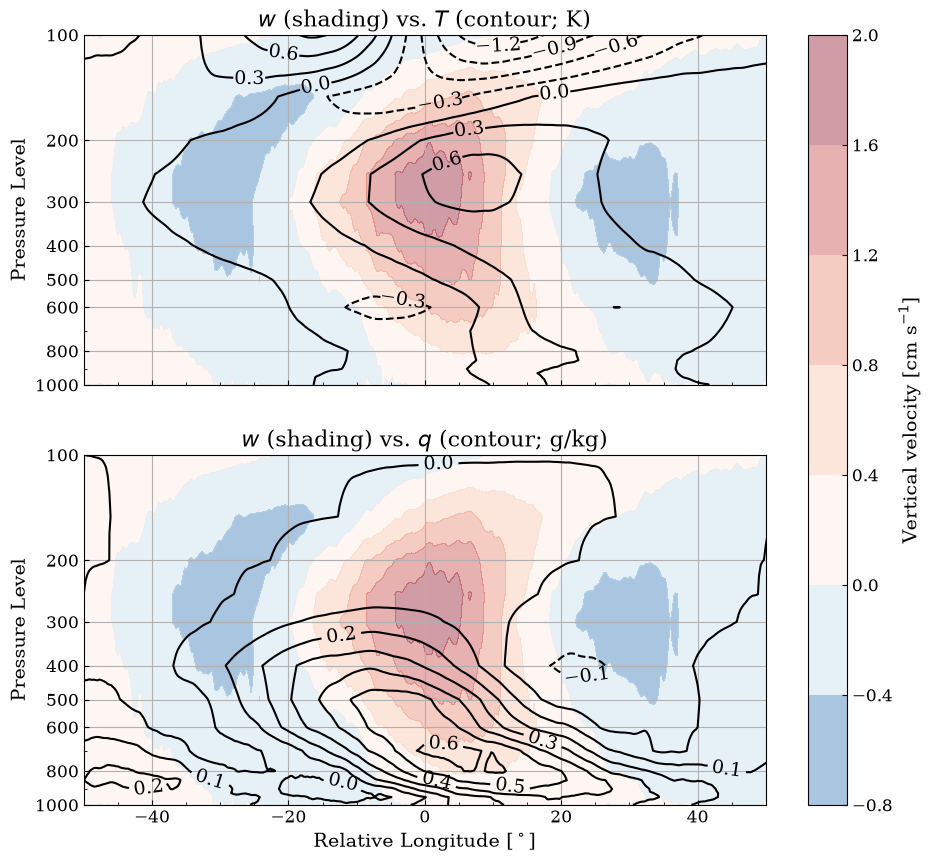

In [11]:
x_rel: np.ndarray = (np.arange(NLON) - NLON // 2) * 0.25
plev: np.ndarray = era5_coords["plev"] / 100.0

# general figure configuration
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)


fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex="col")

ax1, ax2 = axes.flatten()

w_ctf = ax1.contourf(
    x_rel, plev,
    composite["w"] * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )
T_ct = ax1.contour(
    x_rel, plev,
    composite["t"],
    colors="k"
    )
ax1.minorticks_on()
ax1.set_yscale("log")
ax1.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax1.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax1.set_xlim(-50, 50)
ax1.set_ylim(1000, 100)
ax1.set_ylabel("Pressure Level")
ax1.set_title(r"$w$ (shading) vs. $T$ (contour; K)")
ax1.grid()
plt.clabel(T_ct, inline=True)

w_ctf = ax2.contourf(
    x_rel, plev,
    composite["w"] * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )

Q_ct = ax2.contour(
    x_rel, plev,
    composite["q"] * 1e3,
    colors="k"
    )
ax2.minorticks_on()
ax2.set_yscale("log")
ax2.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax2.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax2.set_xlim(-50, 50)
ax2.set_xlabel(r"Relative Longitude [$^\circ$]")
ax2.set_ylim(1000, 100)
ax2.set_ylabel("Pressure Level")
ax2.set_title(r"$w$ (shading) vs. $q$ (contour; g/kg)")
ax2.grid()
fig.colorbar(w_ctf, ax=axes, label=r"Vertical velocity [cm s$^{-1}$]")
plt.clabel(Q_ct, inline=True)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/wTQ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


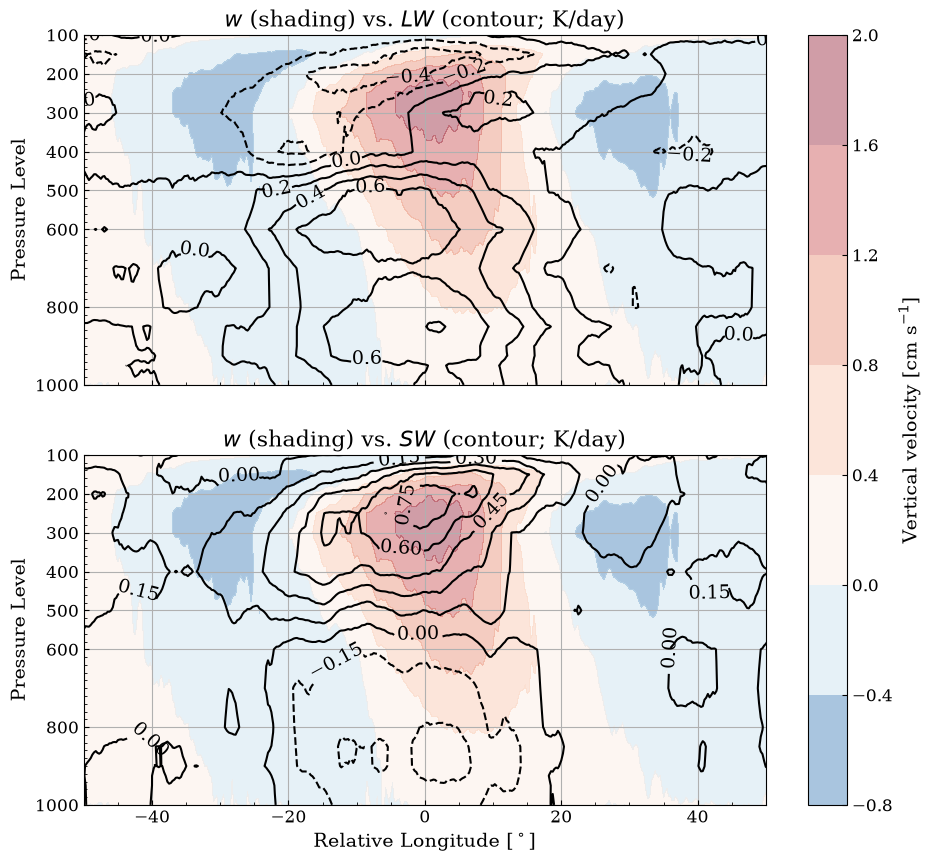

In [13]:

fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex="col")

ax1, ax2 = axes.flatten()

w_ctf = ax1.contourf(
    x_rel, plev,
    composite["w"] * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )
LW_ct = ax1.contour(
    x_rel, plev,
    lw_smoothed,
    colors="k"
    )
ax1.minorticks_on()
ax1.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax1.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax1.set_xlim(-50, 50)
ax1.set_ylim(1000, 100)
ax1.set_ylabel("Pressure Level")
ax1.set_title(r"$w$ (shading) vs. $LW$ (contour; K/day)")
ax1.grid()
plt.clabel(LW_ct, inline=True)

w_ctf = ax2.contourf(
    x_rel, plev,
    composite["w"] * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )

SW_ct = ax2.contour(
    x_rel, plev,
    sw_smoothed,
    colors="k"
    )
ax2.minorticks_on()
ax2.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax2.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax2.set_xlim(-50, 50)
ax2.set_xlabel(r"Relative Longitude [$^\circ$]")
ax2.set_ylim(1000, 100)
ax2.set_ylabel("Pressure Level")
ax2.set_title(r"$w$ (shading) vs. $SW$ (contour; K/day)")
ax2.grid()
fig.colorbar(w_ctf, ax=axes, label=r"Vertical velocity [cm s$^{-1}$]")
plt.clabel(SW_ct, inline=True)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/LWSW_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


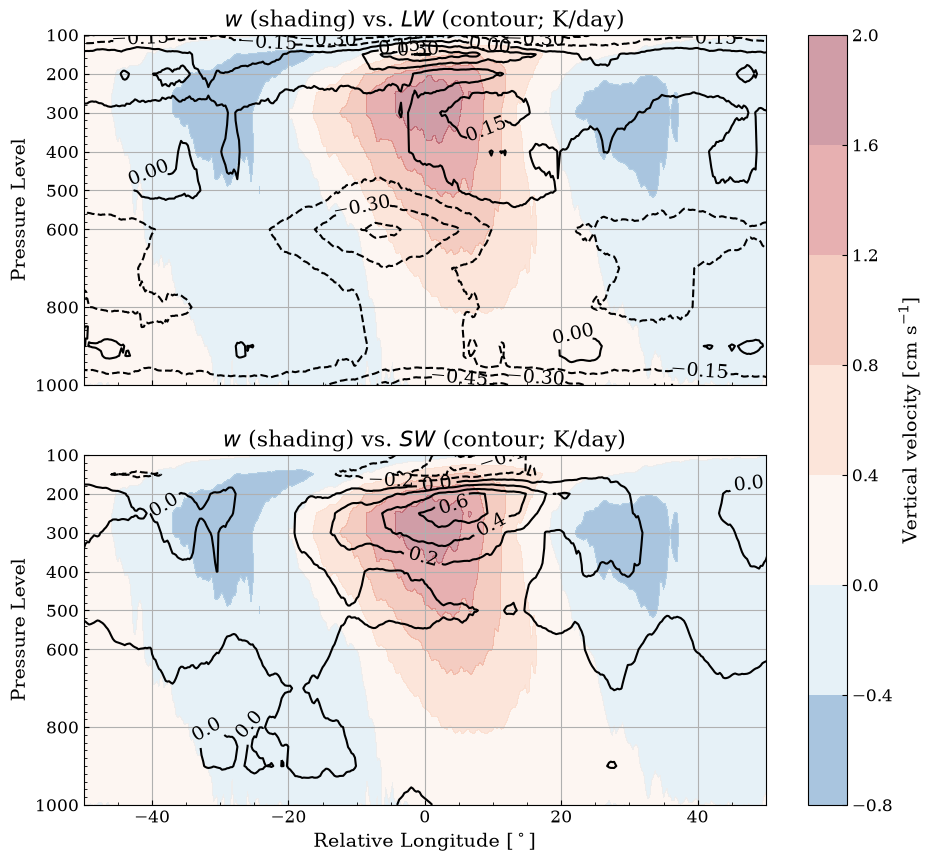

In [14]:

fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex="col")

ax1, ax2 = axes.flatten()

w_ctf = ax1.contourf(
    x_rel, plev,
    composite["w"] * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )
LW_ct = ax1.contour(
    x_rel, plev,
    lw_gen_smoothed,
    colors="k"
    )
ax1.minorticks_on()
ax1.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax1.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax1.set_xlim(-50, 50)
ax1.set_ylim(1000, 100)
ax1.set_ylabel("Pressure Level")
ax1.set_title(r"$w$ (shading) vs. $LW$ (contour; K/day)")
ax1.grid()
plt.clabel(LW_ct, inline=True)

w_ctf = ax2.contourf(
    x_rel, plev,
    composite["w"] * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )

SW_ct = ax2.contour(
    x_rel, plev,
    sw_gen_smoothed,
    colors="k"
    )
ax2.minorticks_on()
ax2.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax2.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax2.set_xlim(-50, 50)
ax2.set_xlabel(r"Relative Longitude [$^\circ$]")
ax2.set_ylim(1000, 100)
ax2.set_ylabel("Pressure Level")
ax2.set_title(r"$w$ (shading) vs. $SW$ (contour; K/day)")
ax2.grid()
fig.colorbar(w_ctf, ax=axes, label=r"Vertical velocity [cm s$^{-1}$]")
plt.clabel(SW_ct, inline=True)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/LWSW_gen_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
